# 🔭 Role 1 — Data Engineer & Preprocessor
### Exoplanet Transit Detection Pipeline

**Deliverables covered in this notebook:**
1. Data ingestion from TESS/Kepler/K2 (lightkurve + astroquery)
2. Detrending pipeline — Wotan (biweight/GP), CBV correction, sigma-clipping
3. Normalization, gap handling, outlier removal, multi-sector stitching
4. Standardized HDF5 dataset schema for downstream roles
5. Data augmentation library (noise injection, time-shift, blending simulation)
6. Validation of transit model outputs + candidate export CSV

---
> **Interface contract**: This notebook produces `/data/processed/` HDF5 files consumed by Role 2 (Feature Engineer) and Role 3 (ML Modeller), and `/data/augmented/` arrays for ML training.


## 0. Install dependencies

In [1]:
# Run once — restart runtime after this cell
!pip install -q lightkurve wotan astropy astroquery h5py batman-package tqdm matplotlib scipy

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 261.1/261.1 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 122.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 76.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.5/89.5 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.9/203.9 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 111.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fss

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
import os
import warnings
from pathlib import Path
from tqdm import tqdm

import lightkurve as lk
from wotan import flatten
from astropy.io import fits
from astropy.stats import sigma_clip
from scipy.interpolate import interp1d

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'axes.facecolor': '#0d1117',
                     'figure.facecolor': '#0d1117', 'text.color': 'white',
                     'axes.labelcolor': 'white', 'xtick.color': 'white',
                     'ytick.color': 'white', 'axes.edgecolor': '#444'})

# ── Directory structure ──────────────────────────────────────────────────────
DIRS = ['data/raw', 'data/processed', 'data/augmented', 'data/exports', 'data/plots']
for d in DIRS:
    Path(d).mkdir(parents=True, exist_ok=True)

print('✅ All imports and directories ready')

/usr/local/lib/python3.12/dist-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


✅ All imports and directories ready


---
## 1. Data Ingestion — TESS / Kepler / K2

Fetches PDCSAP flux (pre-conditioned, systematics removed by pipeline) from MAST. PDCSAP is preferred over SAP for most targets — use SAP only when CBV correction will be done manually.

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# CONFIG — edit these to switch targets / missions
# ─────────────────────────────────────────────────────────────────────────────
TARGET_LIST = [
    {'name': 'Kepler-10', 'mission': 'Kepler'},   # hot rocky planet (Kepler-10b)
    {'name': 'TOI-270',   'mission': 'TESS'},      # 3-planet system
    {'name': 'K2-18',     'mission': 'K2'},        # sub-Neptune in HZ
]

# For a quick demo, override to a single target:
DEMO_TARGET = 'Kepler-10'
DEMO_MISSION = 'Kepler'
FLUX_TYPE = 'PDCSAP_FLUX'   # or 'SAP_FLUX'
EXPTIME = 'long'             # 'long' (30-min) or 'short' (2-min) cadence
MAX_SECTORS = 4              # limit sectors fetched to avoid huge downloads

print(f'Target  : {DEMO_TARGET}')
print(f'Mission : {DEMO_MISSION}')
print(f'Flux    : {FLUX_TYPE}')

Target  : Kepler-10
Mission : Kepler
Flux    : PDCSAP_FLUX


In [4]:
import shutil
cache_dir = '/root/.lightkurve/cache'
shutil.rmtree(cache_dir, ignore_errors=True)
print('Cache cleared')

Cache cleared


In [5]:
def search_and_download(target, mission, flux_type=FLUX_TYPE, exptime=EXPTIME, max_sectors=MAX_SECTORS):
    """
    Search MAST for light curve files, download, and return a list of
    LightCurve objects (one per sector/quarter).
    """
    print(f'\n🔍 Searching MAST for {target} ({mission})...')
    search_result = lk.search_lightcurve(target, mission=mission, exptime=exptime)

    if len(search_result) == 0:
        raise ValueError(f'No data found for {target} on {mission}')

    print(f'  Found {len(search_result)} observations. Downloading first {min(max_sectors, len(search_result))}...')

    lcc = search_result[:max_sectors].download_all()
    lcs = [lcc[i] for i in range(len(lcc))]

    print(f'  ✅ Downloaded {len(lcs)} light curves')
    for i, lc in enumerate(lcs):
        print(f'    [{i}] {len(lc)} cadences  |  t: {lc.time.value[0]:.2f}–{lc.time.value[-1]:.2f}')

    return lcs


raw_lcs = search_and_download(DEMO_TARGET, DEMO_MISSION)


🔍 Searching MAST for Kepler-10 (Kepler)...
  Found 16 observations. Downloading first 4...
  ✅ Downloaded 4 light curves
    [0] 473 cadences  |  t: 120.54–130.25
    [1] 1626 cadences  |  t: 131.51–164.98
    [2] 4075 cadences  |  t: 169.76–258.47
    [3] 4140 cadences  |  t: 260.22–349.50


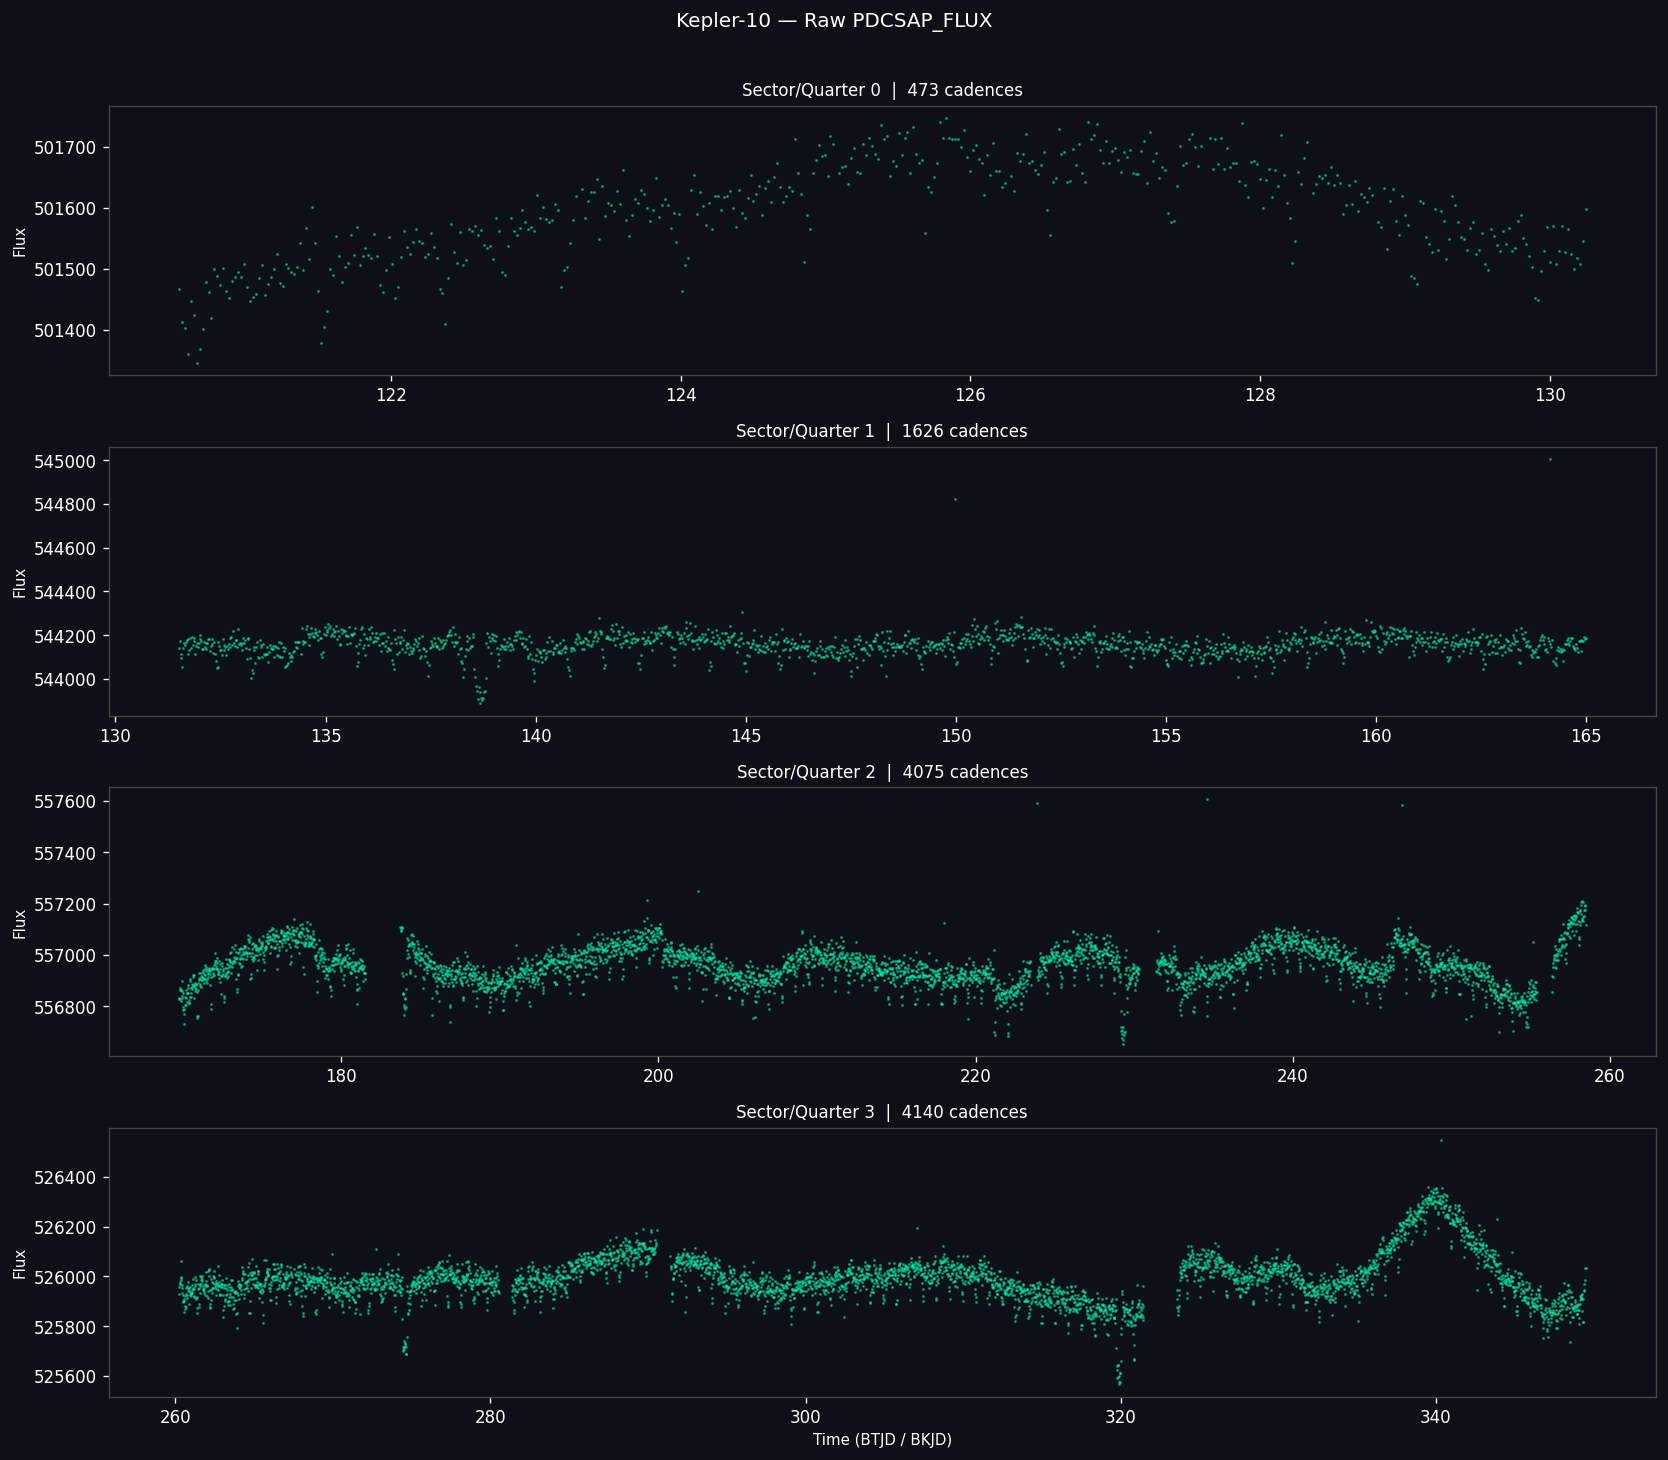

Plot saved → data/plots/01_raw_lightcurves.png


In [6]:
# Quick sanity plot of raw light curves
fig, axes = plt.subplots(len(raw_lcs), 1, figsize=(14, 3 * len(raw_lcs)), sharex=False)
if len(raw_lcs) == 1:
    axes = [axes]

for i, (ax, lc) in enumerate(zip(axes, raw_lcs)):
    ax.plot(lc.time.value, lc.flux.value, 'o', ms=0.8, alpha=0.5, color='#00E5A0')
    ax.set_ylabel('Flux', fontsize=9)
    ax.set_title(f'Sector/Quarter {i}  |  {len(lc)} cadences', fontsize=10)

axes[-1].set_xlabel('Time (BTJD / BKJD)', fontsize=9)
plt.suptitle(f'{DEMO_TARGET} — Raw {FLUX_TYPE}', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('data/plots/01_raw_lightcurves.png', bbox_inches='tight')
plt.show()
print('Plot saved → data/plots/01_raw_lightcurves.png')

---
## 2. Preprocessing — Outlier Removal & Quality Masking

In [7]:
def remove_outliers_and_bad_cadences(lc, sigma=5.0):
    # Step 1: NaN removal
    lc = lc.remove_nans()

    # Step 2: lightkurve's built-in sigma clip
    try:
        lc = lc.remove_outliers(sigma=sigma)
    except Exception:
        pass

    # Step 3: manual clip — fixed for newer astropy
    flux = lc.flux.value.copy()
    median = np.nanmedian(flux)
    std = np.nanstd(flux)
    mask = np.abs(flux - median) < sigma * std
    lc = lc[mask]

    return lc


cleaned_lcs = [remove_outliers_and_bad_cadences(lc) for lc in raw_lcs]

for i, (raw, clean) in enumerate(zip(raw_lcs, cleaned_lcs)):
    removed = len(raw) - len(clean)
    print(f'  Sector {i}: {len(raw)} → {len(clean)} cadences  ({removed} removed, {removed/len(raw)*100:.1f}%)')

  Sector 0: 473 → 469 cadences  (4 removed, 0.8%)
  Sector 1: 1626 → 1617 cadences  (9 removed, 0.6%)
  Sector 2: 4075 → 4067 cadences  (8 removed, 0.2%)
  Sector 3: 4140 → 4133 cadences  (7 removed, 0.2%)


---
## 3. Detrending — Wotan Biweight / GP / CBV

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# Wotan detrending — three methods available, choose per target
# biweight  → robust, fast, good for most cases
# GP        → better for complex stellar variability, but slow
# rspline   → regression spline, good for long-period variability
# ─────────────────────────────────────────────────────────────────────────────

DETREND_METHOD = 'biweight'   # 'biweight' | 'gp' | 'rspline'
WINDOW_LENGTH  = 0.5          # days — should be > transit duration, < variability timescale
                               # typical transit durations: 1–12 hrs, so 0.5d is safe

def detrend_lightcurve(lc, method=DETREND_METHOD, window=WINDOW_LENGTH):
    """
    Detrend a single LightCurve using Wotan.
    Returns (time, flat_flux, trend_flux) as numpy arrays.
    """
    time = lc.time.value
    flux = lc.flux.value

    # Normalize flux to median first (makes window_length scale-invariant)
    flux = flux / np.nanmedian(flux)

    if method == 'biweight':
        flat_flux, trend = flatten(
            time, flux,
            method='biweight',
            window_length=window,
            return_trend=True,
            break_tolerance=0.5   # days — segment at data gaps
        )
    elif method == 'gp':
        flat_flux, trend = flatten(
            time, flux,
            method='gp',
            kernel='matern',
            kernel_size=window,
            return_trend=True
        )
    elif method == 'rspline':
        flat_flux, trend = flatten(
            time, flux,
            method='rspline',
            window_length=window,
            return_trend=True,
            break_tolerance=0.5
        )
    else:
        raise ValueError(f'Unknown detrend method: {method}')

    return time, flat_flux, trend, flux


# Detrend all cleaned sectors
detrended_sectors = []
for i, lc in enumerate(cleaned_lcs):
    print(f'  Detrending sector {i} with {DETREND_METHOD}...', end=' ')
    time, flat_flux, trend, norm_flux = detrend_lightcurve(lc)
    detrended_sectors.append({'time': time, 'flux': flat_flux, 'trend': trend, 'raw_norm': norm_flux})
    print(f'done  (median flat flux: {np.nanmedian(flat_flux):.6f})')

  Detrending sector 0 with biweight... done  (median flat flux: 0.999998)
  Detrending sector 1 with biweight... done  (median flat flux: 0.999999)
  Detrending sector 2 with biweight... done  (median flat flux: 0.999998)
  Detrending sector 3 with biweight... done  (median flat flux: 0.999998)


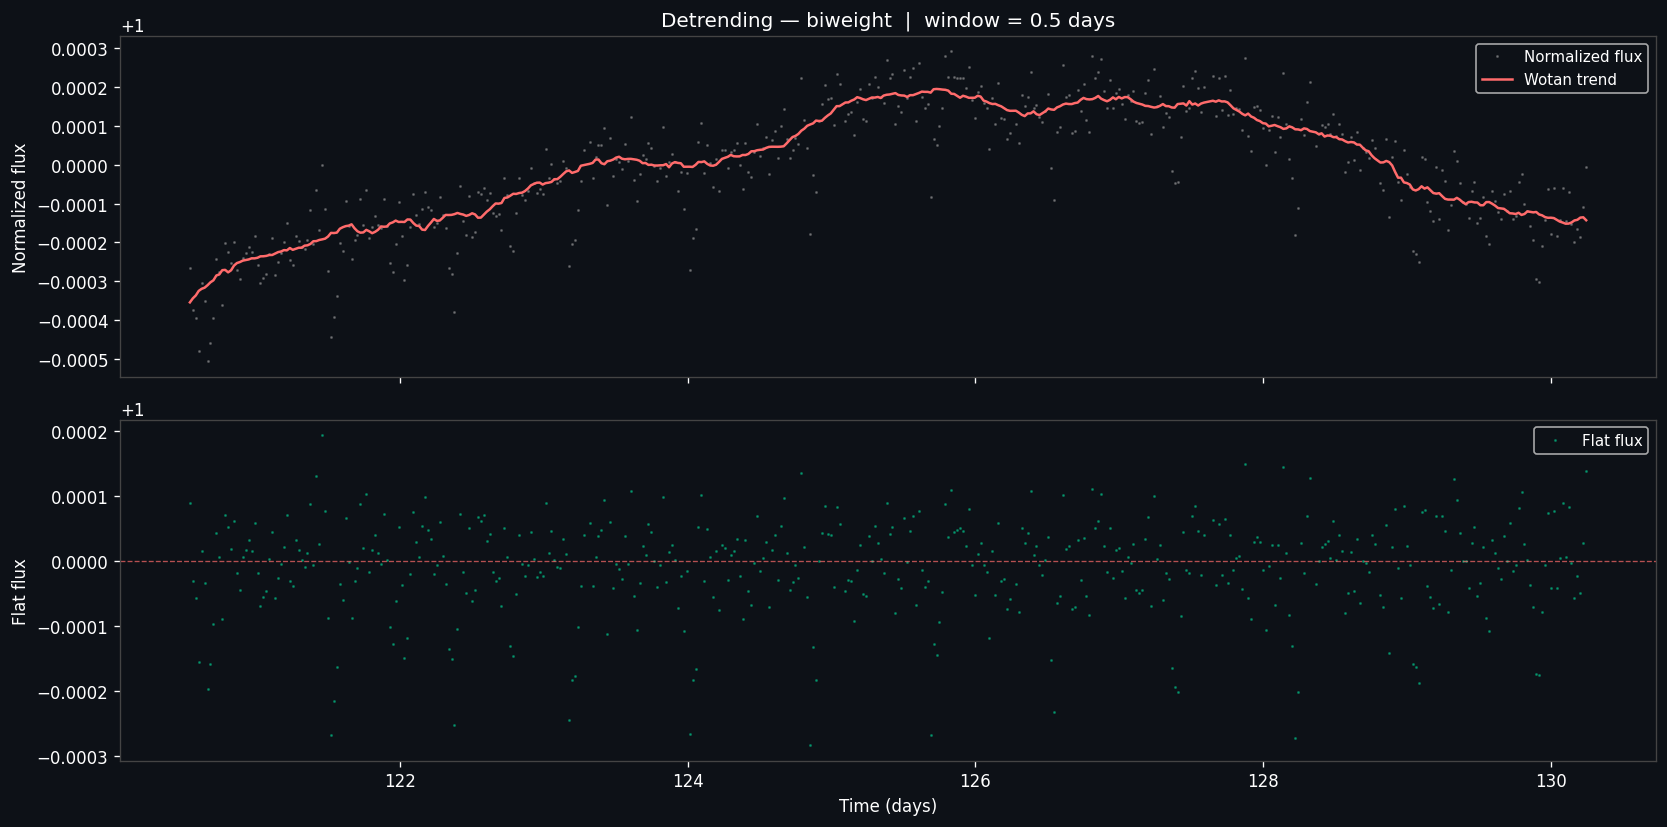

In [9]:
# Visualize detrending for first sector
s = detrended_sectors[0]
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(s['time'], s['raw_norm'], 'o', ms=0.8, alpha=0.4, color='#aaaaaa', label='Normalized flux')
axes[0].plot(s['time'], s['trend'],    '-',  lw=1.5,             color='#FF6B6B', label='Wotan trend')
axes[0].set_ylabel('Normalized flux'); axes[0].legend(fontsize=9)
axes[0].set_title(f'Detrending — {DETREND_METHOD}  |  window = {WINDOW_LENGTH} days')

axes[1].plot(s['time'], s['flux'], 'o', ms=0.8, alpha=0.4, color='#00E5A0', label='Flat flux')
axes[1].axhline(1.0, color='#FF6B6B', lw=0.8, ls='--', alpha=0.7)
axes[1].set_ylabel('Flat flux'); axes[1].set_xlabel('Time (days)'); axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('data/plots/02_detrending.png', bbox_inches='tight')
plt.show()

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# CBV (Co-trending Basis Vectors) correction — TESS/Kepler specific
# CBVs capture systematics shared across many stars on the detector.
# Use when PDCSAP still shows strong systematics.
# ─────────────────────────────────────────────────────────────────────────────

def apply_cbv_correction(lc, n_cbvs=4):
    """
    Apply CBV correction using lightkurve's CBVCorrector.
    Works for TESS and Kepler. Returns corrected LightCurve.
    n_cbvs: number of CBV components to use (2–8 typical)
    """
    try:
        from lightkurve.correctors import CBVCorrector
        corrector = CBVCorrector(lc)
        lc_corrected = corrector.correct(
            cbv_type=['SingleScale'],
            cbv_indices=[np.arange(1, n_cbvs + 1)],
            regularization_weight=1e-4
        )
        print(f'  CBV correction applied ({n_cbvs} components)')
        return lc_corrected
    except Exception as e:
        print(f'  ⚠️  CBV correction failed ({e}) — returning original LC')
        return lc


# NOTE: CBV is optional and adds download overhead.
# Uncomment to apply on the first sector:
# cleaned_lcs[0] = apply_cbv_correction(cleaned_lcs[0])

print('CBV corrector ready. Uncomment the last line to apply.')

CBV corrector ready. Uncomment the last line to apply.


---
## 4. Gap Handling & Multi-Sector Stitching

✅ Stitched light curve: 10286 cadences  |  t: 120.54–349.50 days


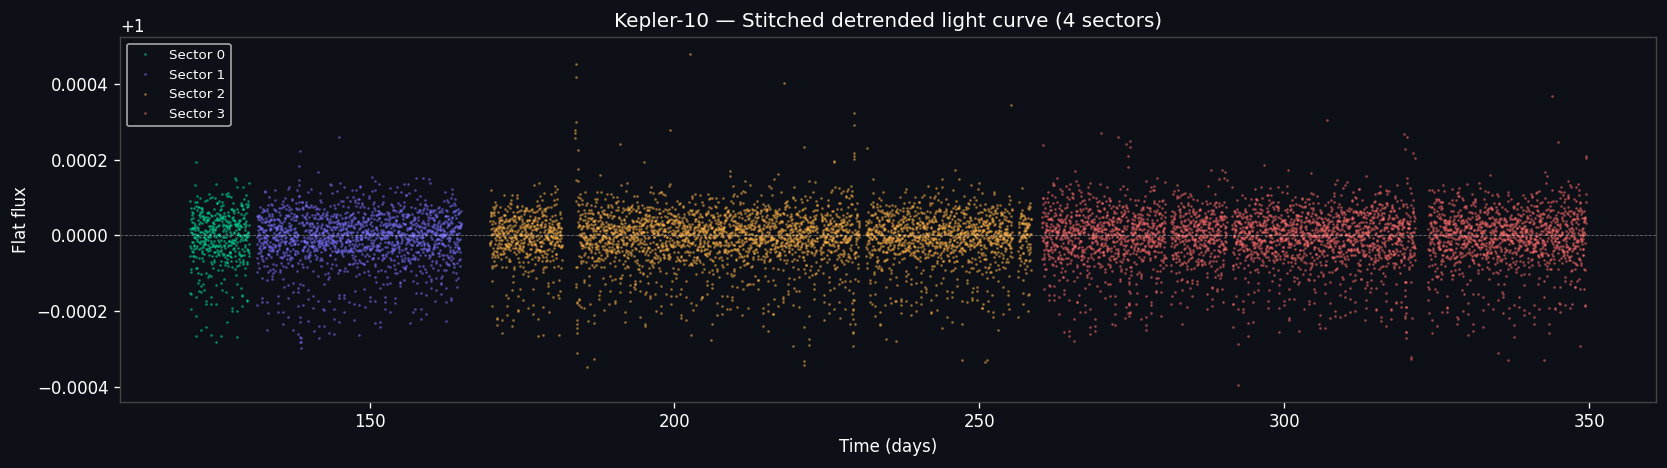

In [11]:
def fill_gaps_linear(time, flux, max_gap_days=0.1, cadence_days=None):
    """
    Identify gaps > max_gap_days and either:
    - Insert NaN markers (for ML models that handle NaN via masking)
    - OR linearly interpolate (for methods requiring uniform sampling)
    Returns (time_filled, flux_filled, gap_mask) where gap_mask=True at inserted points.
    """
    if cadence_days is None:
        cadence_days = np.nanmedian(np.diff(time))  # infer from data

    new_times, new_fluxes, gap_flags = [], [], []

    for i in range(len(time) - 1):
        new_times.append(time[i])
        new_fluxes.append(flux[i])
        gap_flags.append(False)

        gap = time[i + 1] - time[i]
        if gap > max_gap_days:
            # Insert NaN-filled gap markers
            n_fill = int(gap / cadence_days) - 1
            fill_times = np.linspace(time[i] + cadence_days, time[i + 1] - cadence_days, n_fill)
            new_times.extend(fill_times)
            new_fluxes.extend([np.nan] * n_fill)
            gap_flags.extend([True] * n_fill)

    new_times.append(time[-1])
    new_fluxes.append(flux[-1])
    gap_flags.append(False)

    return np.array(new_times), np.array(new_fluxes), np.array(gap_flags)


def stitch_sectors(detrended_sectors, scale_method='median'):
    """
    Stitch multiple detrended sectors into a single time series.
    scale_method: 'median' normalizes each sector to median=1 before stitching.
    Returns (time, flux, sector_ids) as flat arrays.
    """
    all_times, all_fluxes, all_sector_ids = [], [], []

    for sid, s in enumerate(detrended_sectors):
        t = s['time']
        f = s['flux'].copy()

        # Remove NaNs
        valid = np.isfinite(f)
        t, f = t[valid], f[valid]

        # Scale to median
        if scale_method == 'median':
            f = f / np.nanmedian(f)

        all_times.extend(t)
        all_fluxes.extend(f)
        all_sector_ids.extend([sid] * len(t))

    # Sort by time (sectors might not be in order)
    idx = np.argsort(all_times)
    return (np.array(all_times)[idx],
            np.array(all_fluxes)[idx],
            np.array(all_sector_ids)[idx])


# Stitch all detrended sectors
stitched_time, stitched_flux, sector_ids = stitch_sectors(detrended_sectors)
print(f'✅ Stitched light curve: {len(stitched_time)} cadences  |  '
      f't: {stitched_time[0]:.2f}–{stitched_time[-1]:.2f} days')

# Plot stitched
fig, ax = plt.subplots(figsize=(14, 4))
colors = ['#00E5A0', '#7C70FF', '#FFB347', '#FF6B6B']
for sid in np.unique(sector_ids):
    mask = sector_ids == sid
    ax.plot(stitched_time[mask], stitched_flux[mask], 'o', ms=0.6,
            alpha=0.5, color=colors[sid % len(colors)], label=f'Sector {sid}')
ax.axhline(1.0, color='white', lw=0.5, ls='--', alpha=0.4)
ax.set_xlabel('Time (days)'); ax.set_ylabel('Flat flux'); ax.legend(fontsize=8)
ax.set_title(f'{DEMO_TARGET} — Stitched detrended light curve ({len(detrended_sectors)} sectors)')
plt.tight_layout()
plt.savefig('data/plots/03_stitched.png', bbox_inches='tight')
plt.show()

---
## 5. HDF5 Schema — Standardized Output for Role 2 & Role 3

In [12]:
def save_processed_hdf5(target_name, time, flux, sector_ids,
                         detrended_sectors, metadata, outdir='data/processed'):
    """
    Save processed light curve to HDF5 with standardized schema.

    Schema:
    /stitched/
        time          float64[N]   — barycentric time (days)
        flux          float64[N]   — flat normalized flux
        sector_ids    int16[N]     — which sector each cadence belongs to
    /sectors/
        {i}/
            time      float64[Ni]
            flux      float64[Ni]  — flat flux
            trend     float64[Ni]  — wotan trend
            raw_norm  float64[Ni]  — normalized raw flux
    /metadata/
        target_name   str
        mission       str
        flux_type     str
        detrend_method str
        window_length float
        n_sectors     int
        n_cadences    int
        t_start       float
        t_end         float
    """
    safe_name = target_name.replace(' ', '_').replace('-', '_')
    out_path = Path(outdir) / f'{safe_name}_processed.h5'

    with h5py.File(out_path, 'w') as f:
        # Stitched arrays
        grp_stitch = f.create_group('stitched')
        grp_stitch.create_dataset('time',       data=time,       dtype='float64', compression='gzip')
        grp_stitch.create_dataset('flux',       data=flux,       dtype='float64', compression='gzip')
        grp_stitch.create_dataset('sector_ids', data=sector_ids, dtype='int16',   compression='gzip')

        # Per-sector arrays
        grp_sec = f.create_group('sectors')
        for i, s in enumerate(detrended_sectors):
            g = grp_sec.create_group(str(i))
            for key in ['time', 'flux', 'trend', 'raw_norm']:
                arr = s[key]
                valid = np.isfinite(arr)
                g.create_dataset(key, data=arr[valid], dtype='float64', compression='gzip')

        # Metadata
        grp_meta = f.create_group('metadata')
        for k, v in metadata.items():
            grp_meta.attrs[k] = v
        grp_meta.attrs['n_cadences'] = len(time)
        grp_meta.attrs['t_start'] = float(time[0])
        grp_meta.attrs['t_end'] = float(time[-1])

    print(f'✅ Saved → {out_path}  ({out_path.stat().st_size / 1024:.1f} KB)')
    return str(out_path)


# Metadata dict — extend with any additional info per target
meta = {
    'target_name': DEMO_TARGET,
    'mission': DEMO_MISSION,
    'flux_type': FLUX_TYPE,
    'detrend_method': DETREND_METHOD,
    'window_length': WINDOW_LENGTH,
    'n_sectors': len(detrended_sectors),
}

h5_path = save_processed_hdf5(
    DEMO_TARGET, stitched_time, stitched_flux, sector_ids,
    detrended_sectors, meta
)

✅ Saved → data/processed/Kepler_10_processed.h5  (380.5 KB)


In [13]:
# Verify the HDF5 file structure
def inspect_hdf5(path):
    def _print_tree(name, obj):
        indent = '  ' * name.count('/')
        if isinstance(obj, h5py.Dataset):
            print(f'{indent}📊 {name.split("/")[-1]:15s}  shape={obj.shape}  dtype={obj.dtype}')
        elif isinstance(obj, h5py.Group):
            print(f'{indent}📁 {name.split("/")[-1]}/')
    with h5py.File(path, 'r') as f:
        print(f'📦 {path}')
        f.visititems(_print_tree)
        print('\nMetadata attrs:')
        for k, v in f['metadata'].attrs.items():
            print(f'  {k}: {v}')

inspect_hdf5(h5_path)

📦 data/processed/Kepler_10_processed.h5
📁 metadata/
📁 sectors/
  📁 0/
    📊 flux             shape=(469,)  dtype=float64
    📊 raw_norm         shape=(469,)  dtype=float64
    📊 time             shape=(469,)  dtype=float64
    📊 trend            shape=(469,)  dtype=float64
  📁 1/
    📊 flux             shape=(1617,)  dtype=float64
    📊 raw_norm         shape=(1617,)  dtype=float64
    📊 time             shape=(1617,)  dtype=float64
    📊 trend            shape=(1617,)  dtype=float64
  📁 2/
    📊 flux             shape=(4067,)  dtype=float64
    📊 raw_norm         shape=(4067,)  dtype=float64
    📊 time             shape=(4067,)  dtype=float64
    📊 trend            shape=(4067,)  dtype=float64
  📁 3/
    📊 flux             shape=(4133,)  dtype=float64
    📊 raw_norm         shape=(4133,)  dtype=float64
    📊 time             shape=(4133,)  dtype=float64
    📊 trend            shape=(4133,)  dtype=float64
📁 stitched/
  📊 flux             shape=(10286,)  dtype=float64
  📊 sector_ids    

---
## 6. Batch Ingestion — Process Multiple Targets

In [14]:
def process_target(target_name, mission, flux_type='PDCSAP_FLUX',
                   detrend_method='biweight', window=0.5, max_sectors=4):
    """
    Full pipeline for a single target: ingest → clean → detrend → stitch → save.
    Returns path to saved HDF5 file, or None on failure.
    """
    try:
        print(f'\n{'─'*60}')
        print(f'Processing: {target_name} ({mission})')

        lcs_raw = search_and_download(target_name, mission, flux_type, max_sectors=max_sectors)
        lcs_clean = [remove_outliers_and_bad_cadences(lc) for lc in lcs_raw]

        det = []
        for lc in lcs_clean:
            t, f, tr, rn = detrend_lightcurve(lc, method=detrend_method, window=window)
            det.append({'time': t, 'flux': f, 'trend': tr, 'raw_norm': rn})

        st_time, st_flux, st_sids = stitch_sectors(det)

        meta = {
            'target_name': target_name, 'mission': mission,
            'flux_type': flux_type, 'detrend_method': detrend_method,
            'window_length': window, 'n_sectors': len(det)
        }
        h5 = save_processed_hdf5(target_name, st_time, st_flux, st_sids, det, meta)
        return h5

    except Exception as e:
        print(f'  ❌ Failed: {e}')
        return None


# Process all targets in TARGET_LIST
results = {}
for t in TARGET_LIST:
    path = process_target(t['name'], t['mission'])
    results[t['name']] = path

print('\n\n📦 Batch results:')
for name, path in results.items():
    status = '✅' if path else '❌'
    print(f'  {status}  {name:20s}  →  {path}')


────────────────────────────────────────────────────────────
Processing: Kepler-10 (Kepler)

🔍 Searching MAST for Kepler-10 (Kepler)...
  Found 16 observations. Downloading first 4...
  ✅ Downloaded 4 light curves
    [0] 473 cadences  |  t: 120.54–130.25
    [1] 1626 cadences  |  t: 131.51–164.98
    [2] 4075 cadences  |  t: 169.76–258.47
    [3] 4140 cadences  |  t: 260.22–349.50
✅ Saved → data/processed/Kepler_10_processed.h5  (380.5 KB)

────────────────────────────────────────────────────────────
Processing: TOI-270 (TESS)

🔍 Searching MAST for TOI-270 (TESS)...
  Found 30 observations. Downloading first 4...


  ✅ Downloaded 4 light curves
    [0] 880 cadences  |  t: 1385.97–1406.20
    [1] 1025 cadences  |  t: 1410.95–1436.83
    [2] 1174 cadences  |  t: 1438.01–1464.14
    [3] 3681 cadences  |  t: 2115.89–2143.21
✅ Saved → data/processed/TOI_270_processed.h5  (259.5 KB)

────────────────────────────────────────────────────────────
Processing: K2-18 (K2)

🔍 Searching MAST for K2-18 (K2)...
  Found 4 observations. Downloading first 4...
  ❌ Failed: Data product f/root/.lightkurve/cache/mastDownload/HLSP/hlsp_k2varcat_k2_lightcurve_201912552-c01_kepler_v2_llc/hlsp_k2varcat_k2_lightcurve_201912552-c01_kepler_v2_llc.fits of type K2VARCAT is not supported in this version of Lightkurve.


📦 Batch results:
  ✅  Kepler-10             →  data/processed/Kepler_10_processed.h5
  ✅  TOI-270               →  data/processed/TOI_270_processed.h5
  ❌  K2-18                 →  None


---
## 7. Data Augmentation Library

Produces synthetic training data for Role 3's ML models. Augmentation compensates for the severe class imbalance (real transits are rare vs. false positives and non-transit variables).

In [15]:
import batman  # transit model

# ─────────────────────────────────────────────────────────────────────────────
# 7a. Gaussian + red noise injection
# ─────────────────────────────────────────────────────────────────────────────

def inject_gaussian_noise(flux, sigma_ppm=200):
    """Add white Gaussian noise at a given level in ppm."""
    sigma = sigma_ppm * 1e-6
    return flux + np.random.normal(0, sigma, size=flux.shape)


def inject_red_noise(flux, amplitude=3e-4, timescale_pts=30):
    """
    Add correlated (red) noise by smoothing white noise.
    timescale_pts: correlation length in cadences.
    """
    white = np.random.normal(0, amplitude, size=len(flux))
    kernel = np.exp(-np.arange(timescale_pts) / (timescale_pts / 3))
    kernel /= kernel.sum()
    red = np.convolve(white, kernel, mode='same')
    return flux + red


# ─────────────────────────────────────────────────────────────────────────────
# 7b. Time shift (phase randomization)
# ─────────────────────────────────────────────────────────────────────────────

def time_shift(time, flux, shift_days=None):
    """Shift the time axis by a random or fixed amount (for phase augmentation)."""
    if shift_days is None:
        shift_days = np.random.uniform(0, np.ptp(time))
    return time + shift_days, flux


# ─────────────────────────────────────────────────────────────────────────────
# 7c. Stellar blending simulation
# Dilutes a transit by mixing in a constant background flux fraction.
# Simulates a background star contaminating the aperture.
# ─────────────────────────────────────────────────────────────────────────────

def simulate_blending(flux, blend_fraction=None):
    """
    Blend a light curve with a constant background source.
    blend_fraction: fraction of total flux from background (0–0.5).
    Dilutes transit depth by factor (1 - blend_fraction).
    """
    if blend_fraction is None:
        blend_fraction = np.random.uniform(0.0, 0.4)

    # Background star has constant flux = 1.0 (normalized)
    blended = (1 - blend_fraction) * flux + blend_fraction * 1.0
    return blended, blend_fraction


# ─────────────────────────────────────────────────────────────────────────────
# 7d. Transit injection using batman
# Inject a synthetic transit into a real detrended light curve
# ─────────────────────────────────────────────────────────────────────────────

def inject_transit(time, flux, period=None, rp=None, a=None, inc=None, t0=None):
    """
    Inject a batman transit model into an existing light curve.
    Randomly samples parameters if not given.

    Returns (flux_with_transit, params_dict).
    """
    # Random parameter sampling if not provided
    if period is None: period = np.random.uniform(1.0, 30.0)    # days
    if rp     is None: rp     = np.random.uniform(0.01, 0.15)   # Rp/Rs  (depth ~ rp^2)
    if a      is None: a      = np.random.uniform(5.0, 50.0)    # a/Rs
    if inc    is None: inc    = np.random.uniform(85.0, 90.0)   # degrees (near-edge-on)
    if t0     is None: t0     = np.random.uniform(time[0], time[0] + period)

    params = batman.TransitParams()
    params.t0  = t0
    params.per = period
    params.rp  = rp
    params.a   = a
    params.inc = inc
    params.ecc = 0.0
    params.w   = 90.0
    params.limb_dark = 'quadratic'
    params.u         = [0.3, 0.2]   # solar-like limb darkening

    m = batman.TransitModel(params, time)
    transit_model = m.light_curve(params)

    # Multiply into existing flux
    injected_flux = flux * transit_model

    param_dict = {
        't0': t0, 'period': period, 'rp': rp, 'a': a, 'inc': inc,
        'depth_ppm': rp**2 * 1e6, 'duration_days': None  # Role 2 computes this
    }
    return injected_flux, param_dict


# ─────────────────────────────────────────────────────────────────────────────
# 7e. Eclipsing Binary (FP) simulation
# Creates V-shaped or trapezoidal dips mimicking EBs
# ─────────────────────────────────────────────────────────────────────────────

def inject_eclipsing_binary(time, flux, period=None, depth=None, duration=None):
    """
    Inject a trapezoidal eclipse (EB mimic) into a light curve.
    EB signatures: deeper (>1%), V-shaped, odd-even depth differences.
    """
    if period   is None: period   = np.random.uniform(0.5, 20.0)
    if depth    is None: depth    = np.random.uniform(0.005, 0.3)   # 0.5–30%
    if duration is None: duration = np.random.uniform(0.05, 0.15) * period

    t0 = np.random.uniform(time[0], time[0] + period)
    eclipse_flux = flux.copy()

    for t_center in np.arange(t0, time[-1], period):
        t_rel = np.abs(time - t_center)
        in_eclipse = t_rel < (duration / 2)
        # V-shaped: depth proportional to proximity to center
        eclipse_flux[in_eclipse] *= (1 - depth * (1 - t_rel[in_eclipse] / (duration / 2)))

    return eclipse_flux, {'period': period, 'depth': depth, 'duration': duration, 'label': 'EB'}


print('✅ Augmentation functions defined')

✅ Augmentation functions defined


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# 7f. Generate augmented training dataset
# Produces N_AUGMENT samples per class: planet, EB, non-transit variable
# ─────────────────────────────────────────────────────────────────────────────

N_AUGMENT      = 500    # samples per class (increase for real training)
SEGMENT_LENGTH = 2001   # cadences — fixed-length segments for CNN input
SIGMA_NOISE    = 300    # ppm white noise floor


def extract_segment(time, flux, length=SEGMENT_LENGTH):
    """Extract a random segment of fixed length from a stitched light curve."""
    if len(flux) < length:
        # Pad with edge values
        flux_pad = np.pad(flux, (0, length - len(flux)), mode='edge')
        return flux_pad[:length]
    start = np.random.randint(0, len(flux) - length)
    return flux[start:start + length], time[start:start + length]


augmented_X = []   # shape: [N, SEGMENT_LENGTH]
augmented_y = []   # 0=NTP, 1=planet transit, 2=EB
augmented_meta = []

base_flux = stitched_flux.copy()
base_time = stitched_time.copy()

np.random.seed(42)

print(f'Generating {N_AUGMENT * 3} augmented samples...')

for _ in tqdm(range(N_AUGMENT), desc='Non-transiting (NTP)'):
    seg_f, seg_t = extract_segment(base_time, base_flux)
    seg_f = inject_gaussian_noise(seg_f, SIGMA_NOISE)
    seg_f = inject_red_noise(seg_f)
    augmented_X.append(seg_f); augmented_y.append(0)
    augmented_meta.append({'label': 'NTP'})

for _ in tqdm(range(N_AUGMENT), desc='Planet transits  '):
    seg_f, seg_t = extract_segment(base_time, base_flux)
    seg_f = inject_gaussian_noise(seg_f, SIGMA_NOISE)
    seg_f, p = inject_transit(seg_t, seg_f)
    blend_frac = np.random.choice([0.0, np.random.uniform(0, 0.3)], p=[0.6, 0.4])
    if blend_frac > 0:
        seg_f, _ = simulate_blending(seg_f, blend_frac)
        p['blend_fraction'] = blend_frac
    augmented_X.append(seg_f); augmented_y.append(1)
    augmented_meta.append(p)

for _ in tqdm(range(N_AUGMENT), desc='Eclipsing binaries'):
    seg_f, seg_t = extract_segment(base_time, base_flux)
    seg_f = inject_gaussian_noise(seg_f, SIGMA_NOISE)
    seg_f, p = inject_eclipsing_binary(seg_t, seg_f)
    augmented_X.append(seg_f); augmented_y.append(2)
    augmented_meta.append(p)

augmented_X = np.array(augmented_X)
augmented_y = np.array(augmented_y)

print(f'\n✅ Augmented dataset: {augmented_X.shape}  |  labels: {np.bincount(augmented_y)}')

Generating 1500 augmented samples...


Eclipsing binaries: 100%|██████████| 500/500 [00:00<00:00, 4419.88it/s]


✅ Augmented dataset: (1500, 2001)  |  labels: [500 500 500]


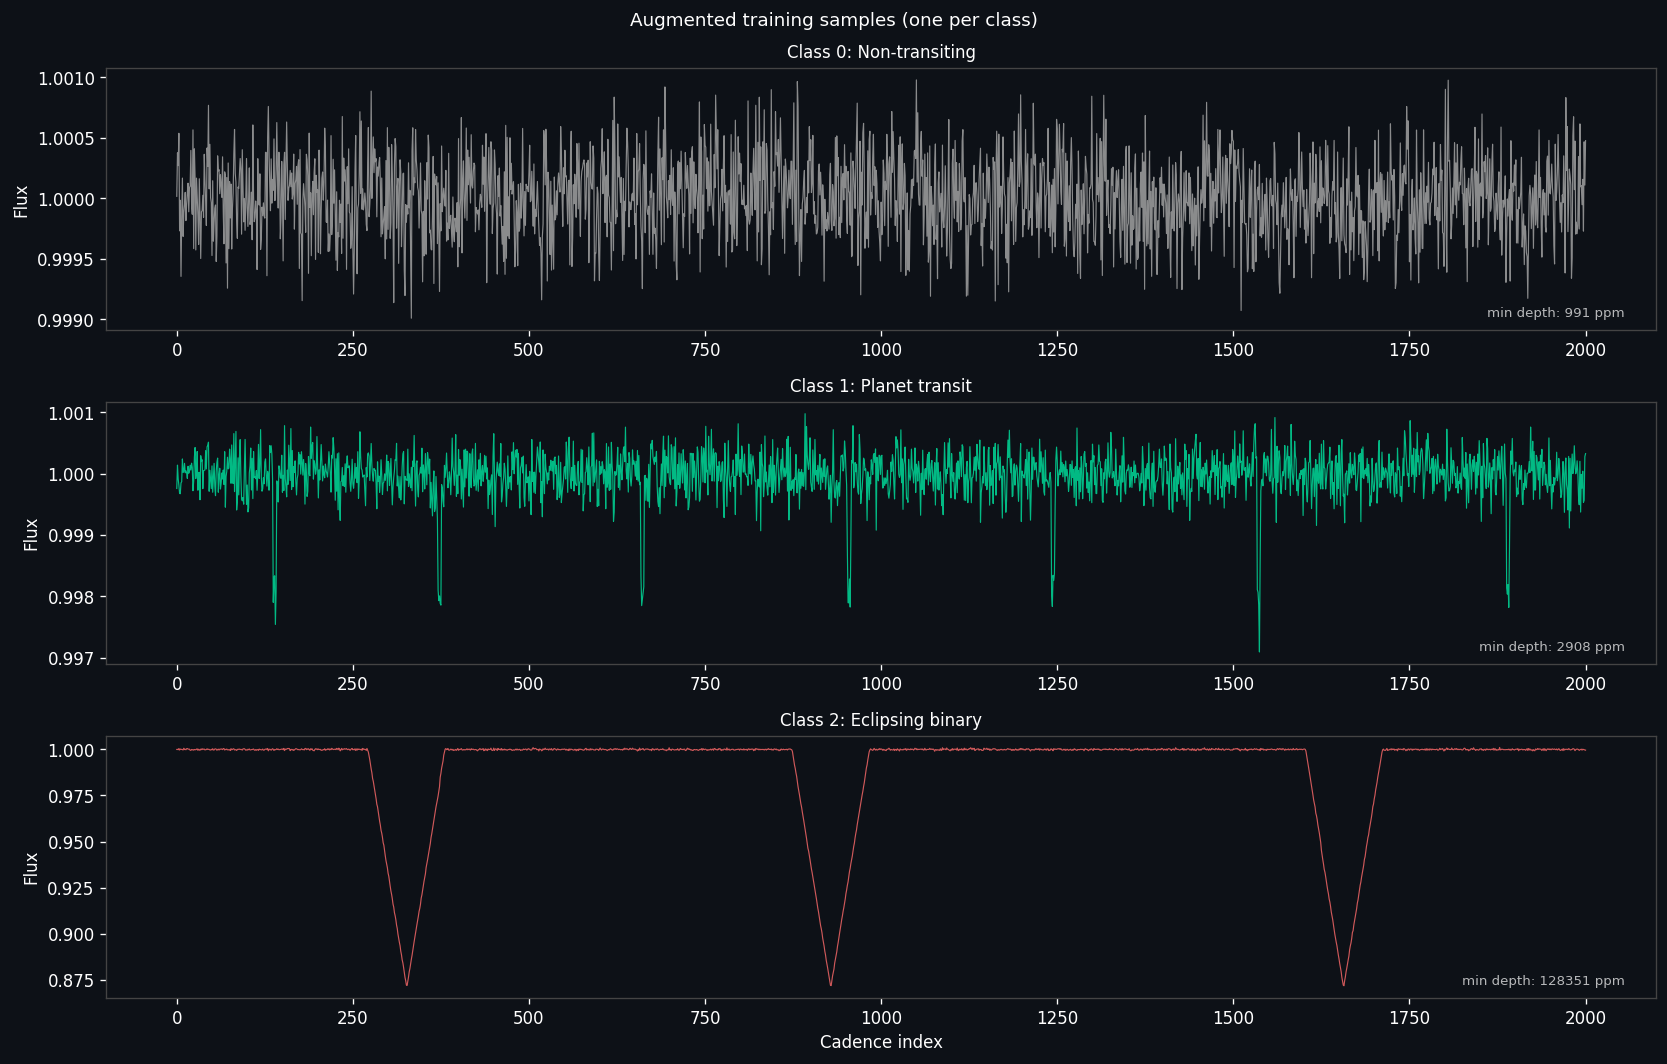

In [17]:
# Visualize one sample from each class
class_names = ['Non-transiting', 'Planet transit', 'Eclipsing binary']
colors_cls  = ['#aaaaaa', '#00E5A0', '#FF6B6B']
fig, axes = plt.subplots(3, 1, figsize=(14, 9))

for cls_id, (ax, name, col) in enumerate(zip(axes, class_names, colors_cls)):
    idx = np.where(augmented_y == cls_id)[0][0]
    ax.plot(augmented_X[idx], '-', lw=0.7, color=col, alpha=0.8)
    ax.set_title(f'Class {cls_id}: {name}', fontsize=10)
    ax.set_ylabel('Flux')
    depth_ppm = (1 - augmented_X[idx].min()) * 1e6
    ax.text(0.98, 0.05, f'min depth: {depth_ppm:.0f} ppm',
            transform=ax.transAxes, ha='right', fontsize=8, color='white', alpha=0.7)

axes[-1].set_xlabel('Cadence index')
plt.suptitle('Augmented training samples (one per class)', fontsize=11)
plt.tight_layout()
plt.savefig('data/plots/04_augmented_samples.png', bbox_inches='tight')
plt.show()

In [18]:
# Save augmented dataset to HDF5
aug_path = 'data/augmented/training_dataset.h5'

with h5py.File(aug_path, 'w') as f:
    f.create_dataset('X', data=augmented_X, dtype='float32', compression='gzip')
    f.create_dataset('y', data=augmented_y, dtype='int8')

    grp = f.create_group('info')
    grp.attrs['classes']        = str(class_names)
    grp.attrs['segment_length'] = SEGMENT_LENGTH
    grp.attrs['n_samples']      = len(augmented_y)
    grp.attrs['sigma_noise_ppm'] = SIGMA_NOISE
    grp.attrs['base_target']    = DEMO_TARGET

size_mb = Path(aug_path).stat().st_size / 1e6
print(f'✅ Augmented dataset saved → {aug_path}  ({size_mb:.1f} MB)')
print(f'   Shape: X={augmented_X.shape}, y={augmented_y.shape}')
print(f'   Class counts: NTP={np.sum(augmented_y==0)}, Planet={np.sum(augmented_y==1)}, EB={np.sum(augmented_y==2)}')

✅ Augmented dataset saved → data/augmented/training_dataset.h5  (7.7 MB)
   Shape: X=(1500, 2001), y=(1500,)
   Class counts: NTP=500, Planet=500, EB=500


---
## 8. Transit Model Validation & Candidate Export

This section validates that batman transit injections are physically consistent, and exports a candidate CSV for Role 4's physical vetting stage.

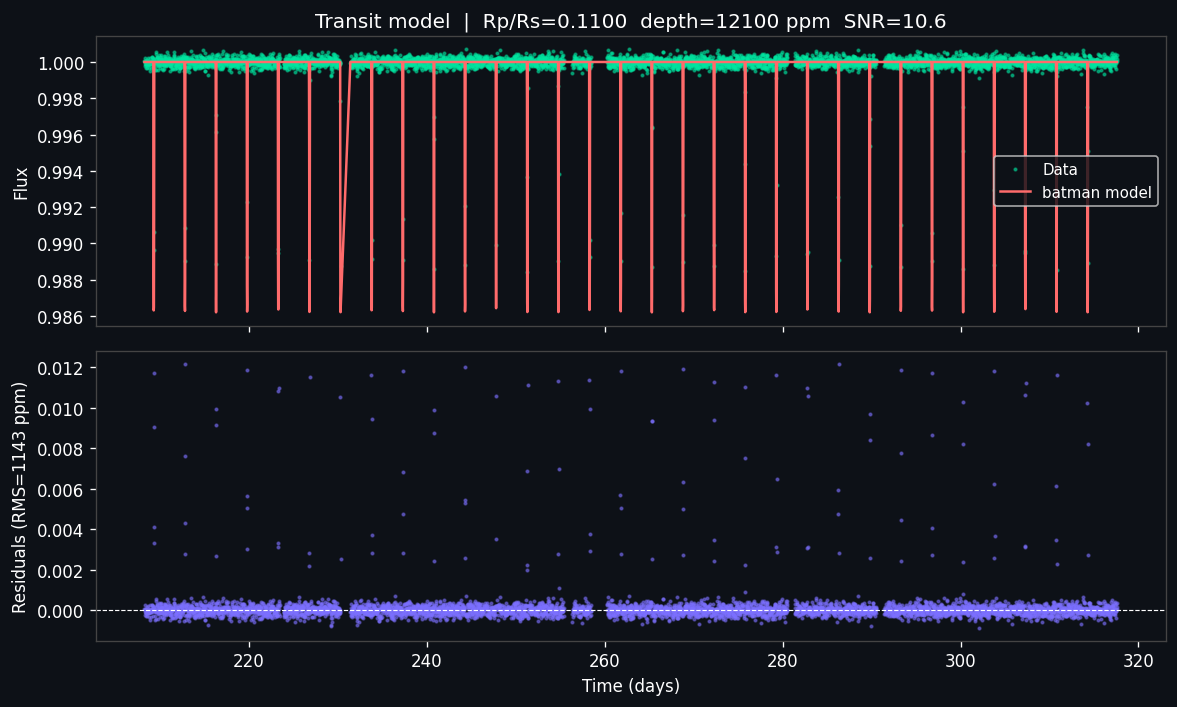


Fit metrics:
  rms_ppm     : 1142.6882
  depth_ppm   : 12100.0000
  snr         : 10.5891
  rp_rs       : 0.1100
  a_rs        : 15.0000
  period      : 3.5000
  t0          : 209.2918
  inc         : 89.0000


In [19]:
def validate_batman_model(time, flux, period, t0, rp, a, inc=89.0,
                           limb_dark=[0.3, 0.2], plot=True):
    """
    Fit a batman transit model to a phase-folded light curve and
    compute residuals. Returns fit quality metrics.
    """
    params = batman.TransitParams()
    params.t0  = t0;  params.per = period; params.rp  = rp
    params.a   = a;   params.inc = inc;    params.ecc = 0.0
    params.w   = 90.0
    params.limb_dark = 'quadratic'
    params.u         = limb_dark

    m = batman.TransitModel(params, time)
    model_flux = m.light_curve(params)

    residuals  = flux - model_flux
    rms        = np.sqrt(np.nanmean(residuals**2))
    depth_ppm  = rp**2 * 1e6
    snr        = depth_ppm / (rms * 1e6) if rms > 0 else 0

    metrics = {
        'rms_ppm'  : rms * 1e6,
        'depth_ppm': depth_ppm,
        'snr'      : snr,
        'rp_rs'    : rp,
        'a_rs'     : a,
        'period'   : period,
        't0'       : t0,
        'inc'      : inc,
    }

    if plot:
        fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
        axes[0].plot(time, flux,        'o', ms=1.5, alpha=0.5, color='#00E5A0', label='Data')
        axes[0].plot(time, model_flux,  '-', lw=1.5, color='#FF6B6B', label='batman model')
        axes[0].set_ylabel('Flux'); axes[0].legend(fontsize=9)
        axes[0].set_title(f'Transit model  |  Rp/Rs={rp:.4f}  depth={depth_ppm:.0f} ppm  SNR={snr:.1f}')
        axes[1].plot(time, residuals, 'o', ms=1.5, alpha=0.5, color='#7C70FF')
        axes[1].axhline(0, color='white', lw=0.7, ls='--')
        axes[1].set_ylabel(f'Residuals (RMS={rms*1e6:.0f} ppm)')
        axes[1].set_xlabel('Time (days)')
        plt.tight_layout()
        plt.savefig('data/plots/05_transit_model_validation.png', bbox_inches='tight')
        plt.show()

    return model_flux, metrics


# Demo validation on a synthetic injected transit
seg_f, seg_t = extract_segment(stitched_time, stitched_flux, length=5000)
demo_period = 3.5; demo_rp = 0.11; demo_a = 15.0
demo_t0 = seg_t[0] + 0.3 * demo_period

injected_f, demo_params = inject_transit(seg_t, seg_f,
    period=demo_period, rp=demo_rp, a=demo_a, t0=demo_t0)
injected_f = inject_gaussian_noise(injected_f, sigma_ppm=200)

model_f, fit_metrics = validate_batman_model(
    seg_t, injected_f, demo_period, demo_t0, demo_rp, demo_a
)

print('\nFit metrics:')
for k, v in fit_metrics.items():
    print(f'  {k:12s}: {v:.4f}')

In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# Candidate export CSV
# Role 1 exports a summary CSV after processing all targets.
# Role 4 ingests this for physical vetting.
# ─────────────────────────────────────────────────────────────────────────────

def export_candidates_csv(candidates, out_path='data/exports/role1_candidates.csv'):
    """
    candidates: list of dicts with keys:
        target_name, h5_path, n_cadences, t_start, t_end,
        n_sectors, detrend_method, noise_rms_ppm, status
    """
    df = pd.DataFrame(candidates)
    df.to_csv(out_path, index=False)
    print(f'✅ Candidates CSV → {out_path}  ({len(df)} rows)')
    return df


# Build candidate list from processed targets
candidate_rows = []
for target_name, h5_path in results.items():
    if h5_path is None:
        continue
    with h5py.File(h5_path, 'r') as f:
        t   = f['stitched/time'][:]
        fx  = f['stitched/flux'][:]
        meta = dict(f['metadata'].attrs)

    noise_rms = np.nanstd(fx) * 1e6  # rough photon noise estimate in ppm
    candidate_rows.append({
        'target_name'     : target_name,
        'h5_path'         : h5_path,
        'n_cadences'      : len(t),
        't_start'         : round(float(t[0]), 3),
        't_end'           : round(float(t[-1]), 3),
        'n_sectors'       : meta.get('n_sectors', '?'),
        'detrend_method'  : meta.get('detrend_method', '?'),
        'noise_rms_ppm'   : round(noise_rms, 1),
        'status'          : 'preprocessed_ready',
    })

# Add the demo validation result
candidate_rows.append({
    'target_name'    : DEMO_TARGET + '_synthetic',
    'h5_path'        : 'synthetic',
    'n_cadences'     : len(seg_t),
    't_start'        : round(float(seg_t[0]), 3),
    't_end'          : round(float(seg_t[-1]), 3),
    'n_sectors'      : 1,
    'detrend_method' : 'biweight',
    'noise_rms_ppm'  : round(fit_metrics['rms_ppm'], 1),
    'status'         : 'batman_validated',
    'batman_rp_rs'   : round(fit_metrics['rp_rs'], 5),
    'batman_depth_ppm': round(fit_metrics['depth_ppm'], 1),
    'batman_snr'     : round(fit_metrics['snr'], 2),
    'batman_period'  : round(fit_metrics['period'], 4),
})

df_candidates = export_candidates_csv(candidate_rows)
df_candidates

✅ Candidates CSV → data/exports/role1_candidates.csv  (3 rows)


,target_name,h5_path,n_cadences,t_start,t_end,n_sectors,detrend_method,noise_rms_ppm,status,batman_rp_rs,batman_depth_ppm,batman_snr,batman_period
0,Kepler-10,data/processed/Kepler_10_processed.h5,10286,120.539,349.496,4,biweight,72.3,preprocessed_ready,NaN,NaN,NaN,NaN
1,TOI-270,data/processed/TOI_270_processed.h5,6047,1385.971,2141.568,4,biweight,594.2,preprocessed_ready,NaN,NaN,NaN,NaN
2,Kepler-10_synthetic,synthetic,5000,208.242,317.580,1,biweight,1142.7,batman_validated,0.11,12100.0,10.59,3.5


---
## 9. Summary & Handoff to Role 2 / Role 3

The cells below print a summary of all outputs produced by this notebook.

In [21]:
from pathlib import Path

print('=' * 60)
print('  ROLE 1 PIPELINE COMPLETE — Handoff summary')
print('=' * 60)

print('\n📁 Processed light curves (→ Role 2, Role 3):')
for p in sorted(Path('data/processed').glob('*.h5')):
    print(f'   {p}  ({p.stat().st_size/1024:.1f} KB)')

print('\n📁 Augmented training data (→ Role 3):')
for p in sorted(Path('data/augmented').glob('*.h5')):
    print(f'   {p}  ({p.stat().st_size/1e6:.2f} MB)')

print('\n📁 Candidate export CSV (→ Role 4):')
for p in sorted(Path('data/exports').glob('*.csv')):
    print(f'   {p}')

print('\n📁 Diagnostic plots:')
for p in sorted(Path('data/plots').glob('*.png')):
    print(f'   {p}')

print()
print('Interface contract for downstream roles:')
print('  Role 2 reads : data/processed/*.h5 → stitched/time, stitched/flux')
print('  Role 3 reads : data/augmented/training_dataset.h5 → X[N, 2001], y[N]')
print('               : data/processed/*.h5 for real inference')
print('  Role 4 reads : data/exports/role1_candidates.csv')

print()
print('HDF5 schema (stitched group):')
print('  time       float64[N]  — BTJD/BKJD days')
print('  flux       float64[N]  — flat normalized, median≈1.0')
print('  sector_ids int16[N]    — sector/quarter index')
print()
print('Augmented dataset schema:')
print('  X  float32[N, 2001]   — fixed-length flux segments')
print('  y  int8[N]            — 0=NTP, 1=planet, 2=EB')

  ROLE 1 PIPELINE COMPLETE — Handoff summary

📁 Processed light curves (→ Role 2, Role 3):
   data/processed/Kepler_10_processed.h5  (380.5 KB)
   data/processed/TOI_270_processed.h5  (259.5 KB)

📁 Augmented training data (→ Role 3):
   data/augmented/training_dataset.h5  (7.75 MB)

📁 Candidate export CSV (→ Role 4):
   data/exports/role1_candidates.csv

📁 Diagnostic plots:
   data/plots/01_raw_lightcurves.png
   data/plots/02_detrending.png
   data/plots/03_stitched.png
   data/plots/04_augmented_samples.png
   data/plots/05_transit_model_validation.png

Interface contract for downstream roles:
  Role 2 reads : data/processed/*.h5 → stitched/time, stitched/flux
  Role 3 reads : data/augmented/training_dataset.h5 → X[N, 2001], y[N]
               : data/processed/*.h5 for real inference
  Role 4 reads : data/exports/role1_candidates.csv

HDF5 schema (stitched group):
  time       float64[N]  — BTJD/BKJD days
  flux       float64[N]  — flat normalized, median≈1.0
  sector_ids int16[N]  

In [22]:
# Download outputs from Colab to local machine
from google.colab import files
import zipfile, os

with zipfile.ZipFile('role1_outputs.zip', 'w', zipfile.ZIP_DEFLATED) as zf:
    for folder in ['data/processed', 'data/augmented', 'data/exports', 'data/plots']:
        for root, dirs, fls in os.walk(folder):
            for file in fls:
                full = os.path.join(root, file)
                zf.write(full, full)

print('✅ Zipped all outputs → role1_outputs.zip')
files.download('role1_outputs.zip')

✅ Zipped all outputs → role1_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>